# CvxSuite daily screens — kink ledger + cross-wrapper breakeven board

**Screens demo notebook** (no QDB engine run here, so the backtest
convention's engine cells d–h are replaced by the screens set d'–h':
assertion battery, two-book summary, styled board, kink-grid chart, gate
lines). Pinned integration date **2026-08-21**. Everything runs offline:
curve store (store-backed asserted), local swaption cube, cached BARCHART
settles under the listed-cache guard — nothing fetches.

**Frozen config (docs/cvxsuite/DESIGN.md section 6, as implemented):**
KINK_GRID as `RVUtils/CvxSuite/grids.py` (17 points, spot 1y → 40y10y);
xsec variant "spline", knots (1, 3, 7, 15, 27); walk-forward PCA n_pcs=2,
window 756, monthly refit; z/pctl and OU windows 756 computed on the
**composed micro-fly of adjusted levels** (`FLY_STATS_WEIGHTS = (-1, +2,
-1)`; section 6's older phrase "on adjusted levels" predates the fly-level
statistics fix and awaits a doc update); FPT sims 2000, steps 504, dt 1.0,
seed 20260826; cost 1x = 2.3 bp package RT **on the belly=+2 ruler L =
2b − f − k (section 6a item 1)**; book clock `max_hold_bd = 63` — `p_hit =
P(hit <= 63bd)` and `edge_bp = e_rev·p_hit − |carry|·min(e_fpt, 63) −
cost` run on the frozen book's own exit clock (section 6a item 2; `e_fpt`
and the `cens` = frac_censored column stay the uncapped 504-step
diagnostics); BookGates re-signed for the receive-belly harvest side
(section 6a item 5): harvest be_over_rv >= 1.17 AND zs >= −0.5 AND
−rac_net > 0 (the `rac_net` COLUMN stays signed for the level-long,
pay-belly holder — the harvest side earns −rac_net); dislocation
|zs| >= 2.0 AND sign-agree AND tag "clean" AND edge >= 1.0 bp. Board
universes: W1
pairs {15Yx5Y/20Yx10Y, 10Yx10Y/20Yx10Y, 10Yx10Y/15Yx10Y}; W2 pack ranks
{1, 5, 9, 13} (Whites/Reds/Greens/Blues, short-CA side); W3 adjacent
KINK_GRID triples; W5 cube points {1yx10y, 5yx10y, 10yx10y}. All vols
bp/day at the ledger boundary.

**What this notebook is allowed to claim:** engine-certified reference
numbers only — **no aliveness claims**. A `book` label is a screen
classification, never a verdict (L-0088 stands: the dislocation book is
machinery awaiting non-flow state data). Incumbent nulls, named: F3 xsec
fade median 63d reversion +0.81..+1.14 bp vs >= 1.0 bp RT (pond equals
boat); W4 rac harvest gross 0.397 < null 0.446 (duration in disguise);
strat1 grid E[max SR | null] = 1.599. DSR accounting at the declared
4-config suite count lives in the engine notebooks; nothing here consumes
a trial.

**Integration references (int1_0 / c23_1 handovers as re-measured on the
section-6a semantics — 2026-08-26 CLI re-run, this date, this machine):**
screen 17 rows — books 1 harvest (20y5y) + 1 dislocation (15y5y) + 15
none (the pre-6a harvest set {4y1y, 5y1y, 8y1y, 9y1y} dissolves under the
re-signed gate: every one fails the receive-side carry floor −rac_net > 0),
units median 4.30 bp/day, cube-support NaNs exactly {1y, 40y10y},
PCA cos_prev ~0.9996/0.9994, CA sigma cells ffilled 68, frontiers
value-carry slope -0.011 r2 0.002 / carry-vol slope -13.282 r2 0.528;
board 13 rows (3 W1 + 4 W2 + 3 W3 + 3 W5), W1 be_over_rv
1.087/1.714/1.976. Printed values below are compared to these in-line;
material drift is reported, not chased.

In [1]:
# (b) setup — offline discipline BEFORE any repo import, then paths, then the
# headless guard (nbclient runs under ipykernel, so figures render inline;
# a bare `python cvx_screens_daily.py` falls back to Agg).
import os

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")

import pathlib
import sys

REPO = pathlib.Path.cwd()
while not (REPO / "RVUtils").exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import dataclasses
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
print(f"repo {REPO}")
print(f"ARBS_SUPABASE_ENABLED={os.environ['ARBS_SUPABASE_ENABLED']}")

repo C:\Users\chris\clee\ARBS-cvxsuite
ARBS_SUPABASE_ENABLED=0


## Config — the frozen section-6 screen config and the pinned date

In [2]:
ASOF = pd.Timestamp("2026-08-21")  # pinned integration date

from RVUtils.CvxSuite import grids
from RVUtils.CvxSuite.kink_screen import (
    FLY_STATS_WEIGHTS,
    KinkScreenCfg,
    build_kink_screen,
)

CFG = KinkScreenCfg()
print(f"asof = {ASOF.date()}   FLY_STATS_WEIGHTS = {FLY_STATS_WEIGHTS}")
print(json.dumps(dataclasses.asdict(CFG), indent=1, default=str))

C:\Users\chris\clee\ARBS-cvxsuite\RVUtils\ConvexityRV\curve_ops.py:61: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


asof = 2026-08-21   FLY_STATS_WEIGHTS = (-1.0, 2.0, -1.0)
{
 "z_window": 756,
 "ou_window": 756,
 "stats_min_obs": 252,
 "xsec_variant": "spline",
 "xsec_knots": [
  1.0,
  3.0,
  7.0,
  15.0,
  27.0
 ],
 "n_pcs": 2,
 "pca_window": 756,
 "pca_min_window": 504,
 "pca_refit": "M",
 "sign_min_abs_bp": 0.5,
 "ca_mode": "panel",
 "ca_ffill_limit": 5,
 "carry_horizon_y": 1.0,
 "carry_horizon_fallback_y": 0.25,
 "frontier_roll_horizon": "1Y",
 "dv01_usd": 100000.0,
 "shifts": [
  -100.0,
  -50.0,
  -25.0,
  -10.0,
  10.0,
  25.0,
  50.0,
  100.0
 ],
 "rlzd_window": 252,
 "rlzd_min_periods": 100,
 "fpt_sims": 2000,
 "fpt_steps": 504,
 "fpt_dt": 1.0,
 "fpt_seed": 20260826,
 "cost_bp": 2.3,
 "max_hold_bd": 63,
 "gates": {
  "harvest_min_be_over_rv": 1.17,
  "harvest_max_z": 0.5,
  "harvest_min_rac_net": 0.0,
  "disl_min_abs_z": 2.0,
  "disl_min_edge_bp": 1.0
 },
 "frontier_min_n": 6,
 "max_ref_date_gap_d": 5
}


## Inputs — leg history, offline store-backed pricer, swaption cube

The pricer asserts are load-bearing: an offline `get_data` for a
non-stored day silently BUILDS a curve (observed on a Saturday probe), so
`from_curve_store is True` and `reference_date == asof` are checked HERE
because the board receives this pricer by injection and its own
`_build_pricer` checks are then bypassed.

In [3]:
LEG_PARQUET = REPO / "docs" / "cvxsuite" / "leg_history.parquet"
leg_hist = pd.read_parquet(LEG_PARQUET)
if not isinstance(leg_hist.index, pd.DatetimeIndex):
    leg_hist.index = pd.DatetimeIndex(pd.to_datetime(leg_hist.index))
print(f"leg history: {leg_hist.shape[0]} days x {leg_hist.shape[1]} legs, "
      f"{leg_hist.index[0].date()}..{leg_hist.index[-1].date()}")
assert ASOF in leg_hist.index, f"pinned asof {ASOF.date()} is not a leg-history date"

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

t0 = time.perf_counter()
pricer = IRSwapsMDP(source="CITIVELO_EXCEL").get_data(
    {"curve_name": "USD-SOFR-1D", "timestamp": ASOF.date(), "offline": True})
assert pricer is not None, f"curve store miss for {ASOF.date()} (get_data returned None)"
meta = pricer.meta()
assert meta.get("from_curve_store") is True, (
    f"pricer for {ASOF.date()} is not store-backed (from_curve_store="
    f"{meta.get('from_curve_store')!r}); offline discipline forbids using it")
ref = pd.Timestamp(pricer.reference_date()).date()
assert ref == ASOF.date(), (
    f"pricer reference date {ref} != asof {ASOF.date()} - a substituted curve "
    "day would silently shift every number")
print(f"pricer: store-backed CITIVELO_EXCEL USD-SOFR-1D @ {ref} "
      f"({time.perf_counter() - t0:.1f}s)")

from Caching.swaption_cube_store import SwaptionCubeStore

store = SwaptionCubeStore.default()
print(f"cube store: {type(store).__name__} (default machine store)")

leg history: 1912 days x 80 legs, 2019-01-02..2026-08-24


pricer: store-backed CITIVELO_EXCEL USD-SOFR-1D @ 2026-08-21 (0.8s)
cube store: SwaptionCubeStore (default machine store)


## (c) The kink-ledger screen — built ONCE, reused by every display

The CA sigma-panel build dominates the runtime (~25s: one
`cube_atm_panel` read over the whole leg history). The frame below feeds
the two-book summary AND the chart — `build_kink_screen` is never called
twice. `df.attrs` are copied IMMEDIATELY after the build: pandas attrs are
not guaranteed to survive sorts/slices/styles.

In [4]:
t0 = time.perf_counter()
screen = build_kink_screen(ASOF, leg_hist_bp=leg_hist, pricer=pricer,
                           cube_store=store, cfg=CFG)
t_screen = time.perf_counter() - t0

ATTRS = dict(screen.attrs)  # read IMMEDIATELY - attrs do not survive pandas ops

print(f"kink screen built in {t_screen:.1f}s - {len(screen)} rows, "
      f"ca_mode={ATTRS['ca_mode']}, sigma cells ffilled={ATTRS['ca_cells_ffilled']} "
      f"(int1_0 reference: 68)")

_LEDGER_COLS = ["tag", "adj_bp", "fly_bp", "residual_xsec", "residual_pca",
                "sign_agree", "zs", "pctl_3y", "carry_bp_day", "e_fpt_d",
                "p_hit", "frac_censored", "e_rev_bp", "rac_net",
                "gamma_usd_per_bp2",
                "sigma_be_bp_day", "be_status", "sigma_impl_bp_day",
                "sigma_rlzd_bp_day", "be_over_rv", "off_value_carry",
                "off_carry_vol", "edge_bp", "book"]
_REN = {"residual_xsec": "res_x", "residual_pca": "res_pca",
        "sign_agree": "agree", "carry_bp_day": "carry/d", "e_fpt_d": "e_fpt",
        "frac_censored": "cens",
        "e_rev_bp": "e_rev", "gamma_usd_per_bp2": "gamma",
        "sigma_be_bp_day": "sig_be", "be_status": "be_st",
        "sigma_impl_bp_day": "sig_impl", "sigma_rlzd_bp_day": "sig_rlzd",
        "off_value_carry": "off_vc", "off_carry_vol": "off_cv"}
ledger = screen[_LEDGER_COLS].copy()
ledger = ledger.loc[ledger["edge_bp"].abs()
                    .sort_values(ascending=False, na_position="last").index]
ledger.rename(columns=_REN).round(2)

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]


kink screen built in 21.6s - 17 rows, ca_mode=panel, sigma cells ffilled=68 (int1_0 reference: 68)


,tag,adj_bp,fly_bp,res_x,res_pca,agree,zs,pctl_3y,carry/d,e_fpt,p_hit,cens,e_rev,rac_net,gamma,sig_be,be_st,sig_impl,sig_rlzd,be_over_rv,off_vc,off_cv,edge_bp,book
point,,,,,,,,,,,,,,,,,,,,,,,,
1y1y,meeting,416.92,14.21,0.92,15.74,1.0,1.96,0.95,0.12,47.99,0.76,0.00,28.88,-18.48,1.74,0.00,always_cheap,5.97,5.48,0.00,0.82,-4.23,14.11,none
25y5y,convexity,653.20,-3.79,4.12,6.33,1.0,-1.94,0.01,0.04,24.52,0.94,0.00,10.91,10.61,-292.79,4.98,root,4.95,4.74,1.05,4.27,5.25,7.04,none
15y5y,clean,604.08,5.26,-2.09,-8.25,-1.0,-2.14,0.01,0.03,8.76,1.00,0.00,7.91,8.35,258.71,0.00,always_cheap,5.25,4.48,0.00,-1.99,4.66,5.32,dislocation
7y1y,clean,480.49,-1.23,-1.95,-10.98,-1.0,-0.23,0.38,0.01,5.53,1.00,0.00,0.19,0.19,2.45,0.00,always_cheap,5.66,3.82,0.00,-2.00,-3.61,-2.14,none
6y1y,clean,465.40,0.18,0.18,-10.58,0.0,-0.25,0.48,0.00,5.57,1.00,0.00,0.23,0.18,1.26,0.00,always_cheap,5.71,3.98,0.00,0.12,-3.70,-2.07,none
8y1y,clean,496.81,-0.10,-2.18,-11.54,-1.0,-0.36,0.40,-0.00,4.62,1.00,0.00,0.29,0.25,2.32,18.80,root,5.62,4.02,4.68,-2.24,-4.69,-2.03,none
9y1y,clean,513.24,-8.55,-1.54,-13.53,-1.0,-0.48,0.33,-0.02,5.72,1.00,0.00,0.46,0.30,-106.06,inf,never_cheap,5.57,3.89,inf,-1.59,-4.71,-1.94,none
3y1y,clean,423.31,-6.25,-0.28,2.28,0.0,-0.23,0.42,0.01,8.28,0.99,0.00,0.70,0.53,2.11,0.00,always_cheap,5.95,4.41,0.00,-0.26,7.26,-1.70,none
4y1y,clean,434.73,-3.96,0.90,-3.73,0.0,-0.42,0.34,-0.01,4.26,1.00,0.00,0.64,0.62,0.97,37.85,root,5.87,4.38,8.65,0.87,0.90,-1.69,none


## The cross-wrapper breakeven board

Same pricer / leg history / cube store injected (no rebuild). W2 walks the
cached SR3 settle history under the listed-cache guard — a miss never
fetches. Skip/note lines print inline; `board.attrs` copied immediately.

In [5]:
from RVUtils.CvxSuite.board import (
    CITI_ANCHOR_LINES,
    BoardConfig,
    board_priced,
    build_breakeven_board,
)

BCFG = BoardConfig(leg_hist=leg_hist, pricer=pricer, cube_store=store)
t0 = time.perf_counter()
board = build_breakeven_board(ASOF.date(), cfg=BCFG)
t_board = time.perf_counter() - t0

BOARD_ATTRS = dict(board.attrs)  # read IMMEDIATELY, same warning as the screen

wrapper_counts = board["wrapper"].value_counts().to_dict()
print(f"board built in {t_board:.1f}s - {len(board)} rows by wrapper: "
      f"{wrapper_counts} (c23_1 reference: 3 W1 + 4 W2 + 3 W3 + 3 W5)")

W2 note: Whites (rank 1) has no one-nearer window - theta (CA roll) is NaN
board built in 3.4s - 13 rows by wrapper: {'W2': 4, 'W1': 3, 'W3': 3, 'W5': 3} (c23_1 reference: 3 W1 + 4 W2 + 3 W3 + 3 W5)


## (d') Assertion battery

The screens-notebook battery: the screen returned one row per KINK_GRID
point with finite `sigma_rlzd` sitting inside the units guard, and the
board priced at least W1.

In [6]:
from RVUtils.CvxSuite.vols import units_median_guard

# screen shape: one row per grid point, in grid order
grid_labels = [grids.leg_label(p) for p in grids.KINK_GRID]
assert len(screen) == len(grids.KINK_GRID), (
    f"screen returned {len(screen)} rows, expected {len(grids.KINK_GRID)}")
assert list(screen.index) == grid_labels, "screen index is not KINK_GRID order"

# sigma_rlzd: finite everywhere (endpoints included) and inside the units guard
rlzd = screen["sigma_rlzd_bp_day"].astype(float)
assert np.isfinite(rlzd).all(), (
    f"non-finite sigma_rlzd at {list(screen.index[~np.isfinite(rlzd)])}")
units_median_guard(rlzd)  # raises ValueError naming the median on a breach

# the board priced at least W1
w1 = board[board["wrapper"] == "W1"]
assert len(w1) > 0, "board priced no W1 rows"
assert np.isfinite(w1["sigma_be"].astype(float)).all(), "W1 sigma_be not finite"
assert board_priced(board), "board_priced is False - nothing priced"

n_theta = int(screen["theta_usd_day"].notna().sum())
assert n_theta > 0, "every fly theta is NaN - the curve expressed no package"
print(f"PASS: screen {len(screen)}/{len(grids.KINK_GRID)} rows in grid order; "
      f"sigma_rlzd finite 17/17, median {np.nanmedian(rlzd):.2f} bp/day in [0.5, 40] "
      f"(int1_0 reference: 4.30)")
print(f"PASS: {n_theta} interior flies priced theta (expected 15); "
      f"board priced {len(w1)} W1 rows, board_priced=True")

PASS: screen 17/17 rows in grid order; sigma_rlzd finite 17/17, median 4.30 bp/day in [0.5, 40] (int1_0 reference: 4.30)
PASS: 15 interior flies priced theta (expected 15); board priced 3 W1 rows, board_priced=True


## (e') Two-book summary

A `book` label is a screen classification — never an aliveness claim.
Section-6a reference at this date: harvest {20y5y}, dislocation {15y5y},
15 none. On a fly, harvest = RECEIVING the belly = SHORT the level, so the
re-signed gate (6a item 5) wants a CHEAP belly (zs >= −0.5) that PAYS the
receive side (−rac_net > 0): 20y5y qualifies (zs +1.65, −rac_net +6.25bp)
and is also the one real-data row where the 63bd hold cap bites (e_fpt
64.3 > 63, so carry is charged over 63bd). The pre-6a harvest set {4y1y,
5y1y, 8y1y, 9y1y} — rows where the receive side BLEEDS — all fail the
carry floor (−rac_net ≤ 0; 5y1y also fails zs >= −0.5). 9y1y's
be_over_rv = inf (the never_cheap tenor-break package; the recorded
books-layer question, shown unedited) still passes the be gate but no
longer books harvest: the receive side bleeds 0.30bp.

In [7]:
_SUMMARY_COLS = ["tag", "zs", "pctl_3y", "be_over_rv", "rac_net", "e_rev_bp",
                 "p_hit", "e_fpt_d", "carry_bp_day", "edge_bp"]
picked = screen[screen["book"].isin(["harvest", "dislocation"])]
two_book = (picked[["book"] + _SUMMARY_COLS]
            .sort_values(["book", "edge_bp"], ascending=[True, False]))
n_none = int((screen["book"] == "none").sum())
print(f"harvest rows: {int((screen['book'] == 'harvest').sum())}   "
      f"dislocation rows: {int((screen['book'] == 'dislocation').sum())}   "
      f"none: {n_none}   (section-6a reference: 1 / 1 / 15 — pre-6a 4/1/12 "
      f"superseded by the re-signed harvest gate)")
two_book.round(2)

harvest rows: 1   dislocation rows: 1   none: 15   (section-6a reference: 1 / 1 / 15 — pre-6a 4/1/12 superseded by the re-signed harvest gate)


,book,tag,zs,pctl_3y,be_over_rv,rac_net,e_rev_bp,p_hit,e_fpt_d,carry_bp_day,edge_bp
point,,,,,,,,,,,
15y5y,dislocation,clean,-2.14,0.01,0.00,8.35,7.91,1.00,8.76,0.03,5.32
20y5y,harvest,convexity,1.65,0.98,1.78,-6.25,7.15,0.69,64.32,-0.02,1.43


## (f') Breakeven board, styled against the reference anchors

Citi's published thresholds are CURVE-PAIR anchors: be_over_rv <= 0.80
buys convexity (green), >= 1.17 sells it (orange). They were derived on
DV01-neutral forward-curve pairs with the longer rate as ruler — **not
validated on micro-flies**, and W3's ratio is not even the same units
(parallel-shift breakeven over the fly's OWN level vol), so W3 highlights
are expected to scream and mean nothing.

In [8]:
_NUM_COLS = ["theta_bp_yr", "gamma_usd_bp2", "sigma_be", "sigma_impl",
             "sigma_rlzd", "be_over_rv", "impl_over_rv", "z"]


def _anchor_style(col: pd.Series) -> list:
    out = []
    for v in col:
        if pd.isna(v):
            out.append("")
        elif v <= 0.80:
            out.append("background-color: #c8e6c9")   # buys convexity
        elif v >= 1.17:
            out.append("background-color: #ffe0b2")   # sells convexity
        else:
            out.append("")
    return out


for line in CITI_ANCHOR_LINES:
    print(line)
print("W3 caveat: be_over_rv mixes a PARALLEL-shift breakeven with the fly's own "
      "level vol; near-zero-gamma flies (15y5y/20y5y/25y5y) make it explosive - "
      "not comparable to W1's like-for-like ratio (c23_1 open risk 3)")
print("W2 caveat: the Whites CA-implied vol is inflated by its tiny time-weight "
      "window; Citi's own screen starts at rank 5 (c23_1 open risk 2)")

(board.style
 .format({c: "{:.3f}" for c in _NUM_COLS}, na_rep="")
 .apply(_anchor_style, subset=["be_over_rv"]))

reference: be_over_rv <= 0.80 buys convexity (long-gamma entry; Citi Doc C entry 0.42-0.45, exit 0.80)
reference: be_over_rv >= 1.17-1.38 sells convexity (harvest gate; kink_ledger BookGates 1.17)
curve-pair anchors (0.8 long / 1.17-1.38 short) - not validated on micro-flies
W3 caveat: be_over_rv mixes a PARALLEL-shift breakeven with the fly's own level vol; near-zero-gamma flies (15y5y/20y5y/25y5y) make it explosive - not comparable to W1's like-for-like ratio (c23_1 open risk 3)
W2 caveat: the Whites CA-implied vol is inflated by its tiny time-weight window; Citi's own screen starts at rank 5 (c23_1 open risk 2)


,structure,wrapper,theta_bp_yr,gamma_usd_bp2,sigma_be,sigma_impl,sigma_rlzd,be_over_rv,impl_over_rv,z,tag
0,15Yx5Y/20Yx10Y,W1,-2.419,147.049,3.613,5.253,3.325,1.087,1.580,1.390,flattener
1,10Yx10Y/20Yx10Y,W1,-8.347,204.072,5.697,5.303,3.325,1.714,1.595,1.413,flattener
2,10Yx10Y/15Yx10Y,W1,-6.201,101.841,6.951,5.303,3.518,1.976,1.507,1.459,flattener
3,sr3-whites-pack-ca,W2,,,19.438,19.438,4.582,4.242,4.242,,short-ca U6-M7
4,sr3-reds-pack-ca,W2,-1.797,,6.218,6.218,5.032,1.236,1.236,,short-ca U7-M8
5,sr3-greens-pack-ca,W2,4.097,,5.385,5.385,4.752,1.133,1.133,,short-ca U8-M9
6,sr3-blues-pack-ca,W2,4.144,,6.488,6.488,4.634,1.400,1.400,,short-ca U9-M0
7,5y1y/6y1y/7y1y,W3,0.175,-0.029,48.528,5.706,0.844,57.479,6.759,-0.111,clean
8,10y2y/12y3y/15y5y,W3,-3.478,15.686,9.380,5.438,1.801,5.207,3.019,0.084,clean
9,15y5y/20y5y/25y5y,W3,-3.581,0.327,65.936,5.100,1.685,39.134,3.027,1.591,convexity


## (g') The kink grid — adjusted forward curve, residual bars, book labels

Left axis: the convexity-adjusted forward curve (quoted + Ho-Lee CA)
against the fit abscissa `k = fwd + tenor/2`; the quoted curve is dashed
underneath, so the widening wedge at the long end IS the CA. Right axis:
per-point cross-sectional spline residual (`res_x`, bp; > 0 = cheap), bars
coloured by book. Shaded zones: meeting (fwd < 2y) and convexity
(fwd >= 20y) — points the books refuse by tag.

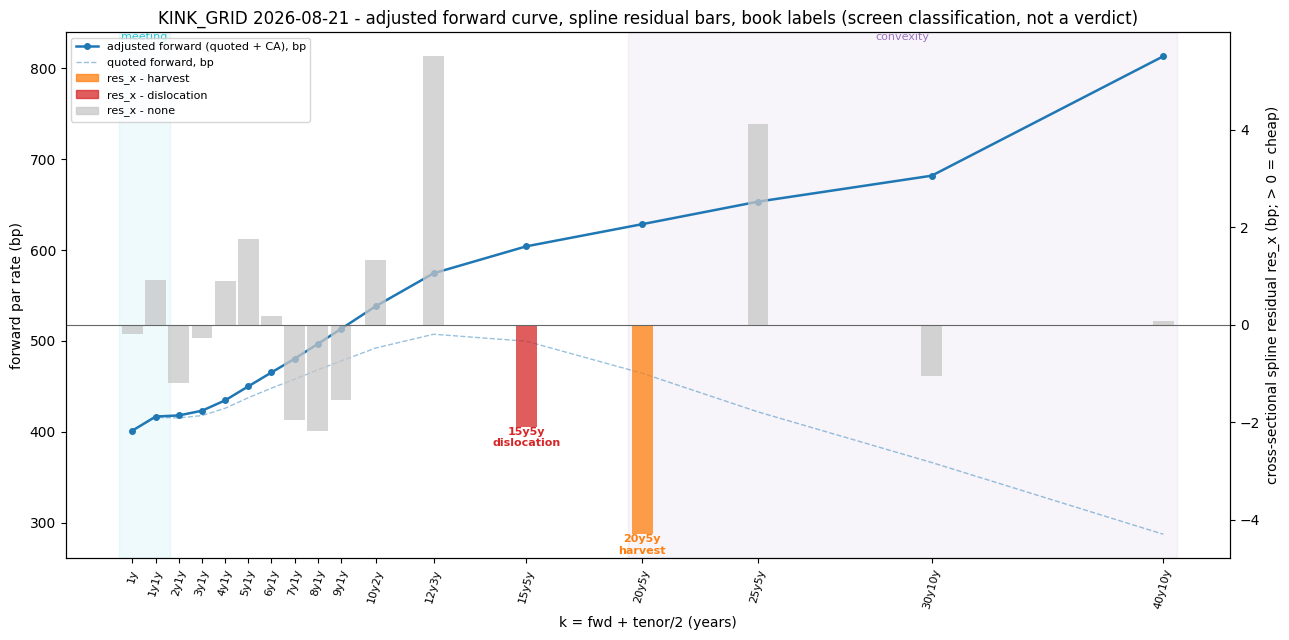

In [9]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6.5))
k = screen["k_coord"].to_numpy(dtype=float)

ax.plot(k, screen["adj_bp"], "-o", color="tab:blue", lw=1.8, ms=4,
        label="adjusted forward (quoted + CA), bp", zorder=3)
ax.plot(k, screen["level_bp"], "--", color="tab:blue", lw=1.0, alpha=0.45,
        label="quoted forward, bp", zorder=2)
ax.set_xlabel("k = fwd + tenor/2 (years)")
ax.set_ylabel("forward par rate (bp)")
ax.set_xticks(k)
ax.set_xticklabels(screen.index, rotation=75, fontsize=8)

for tag, colr in (("meeting", "tab:cyan"), ("convexity", "tab:purple")):
    kk = screen.loc[screen["tag"] == tag, "k_coord"]
    if len(kk):
        ax.axvspan(kk.min() - 0.6, kk.max() + 0.6, color=colr, alpha=0.07)
        ax.text((kk.min() + kk.max()) / 2, ax.get_ylim()[1], tag, ha="center",
                va="top", fontsize=8, color=colr, alpha=0.9)

_BOOK_COLOR = {"harvest": "tab:orange", "dislocation": "tab:red", "none": "0.78"}
ax2 = ax.twinx()
ax2.bar(k, screen["residual_xsec"], width=0.9,
        color=[_BOOK_COLOR[b] for b in screen["book"]], alpha=0.75, zorder=1)
ax2.axhline(0.0, color="0.4", lw=0.8)
ax2.set_ylabel("cross-sectional spline residual res_x (bp; > 0 = cheap)")
for lab, r in screen.iterrows():
    if r["book"] != "none":
        y = r["residual_xsec"]
        ax2.annotate(f"{lab}\n{r['book']}", (r["k_coord"], y), fontsize=8,
                     ha="center", va="bottom" if y >= 0 else "top",
                     color=_BOOK_COLOR[r["book"]], fontweight="bold")

handles, labels_ = ax.get_legend_handles_labels()
handles += [Patch(color=_BOOK_COLOR["harvest"], alpha=0.75, label="res_x - harvest"),
            Patch(color=_BOOK_COLOR["dislocation"], alpha=0.75, label="res_x - dislocation"),
            Patch(color=_BOOK_COLOR["none"], alpha=0.75, label="res_x - none")]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_title(f"KINK_GRID {ASOF.date()} - adjusted forward curve, spline residual "
             "bars, book labels (screen classification, not a verdict)")
fig.tight_layout()
plt.show()

## (h') Gate lines

The CLI's `=== GATE ... ===` lines, rebuilt from the LIBRARY gate
functions and the immediately-captured `ATTRS` — plus the eigenvector
continuity gate on the walk-forward PCA (the thresholded check the recon
found missing everywhere), and the board's skip/note ledger.

In [10]:
from RVUtils.CvxSuite import gates as G

try:
    units_median_guard(rlzd)
    print(f"=== GATE units_median_guard(sigma_rlzd) === PASS  "
          f"median={np.nanmedian(rlzd):.2f} bp/day in [0.5, 40]")
except ValueError as exc:
    print(f"=== GATE units_median_guard(sigma_rlzd) === FAIL  {exc}")

dg = G.degeneracy_gate(rlzd)
fails = list(screen.index[~dg])
print(f"=== GATE degeneracy (sigma_rlzd >= 0.25 bp/day) === "
      f"{int(dg.sum())}/{len(screen)} pass" + (f"  FAILING: {fails}" if fails else ""))

nan_impl = sorted(screen.index[screen["sigma_impl_bp_day"].isna()])
expected_nan = {"1y", "40y10y"}
note = ("as designed (1y: expiry 0 < 1M axis; 40y10y: expiry 40 > 30Y axis)"
        if set(nan_impl) == expected_nan
        else f"UNEXPECTED (design expects exactly {sorted(expected_nan)})")
print(f"=== GATE cube support === {len(nan_impl)} NaN sigma_impl of {len(screen)}: "
      f"{nan_impl} - {note}")

lev = ATTRS["fit_diag"]["leverage"]
hi = ", ".join(f"k={kk:g}: h={v:.3f}" for kk, v in sorted(lev.items()) if kk >= 27.0)
print(f"=== GATE spline leverage (k >= 27, cubic extension) === {hi}  "
      f"(model_dof={ATTRS['fit_diag']['model_dof']:.2f})")

pinfo = ATTRS["pca_info"]
cos_prev = pinfo.get("cos_prev", {})
print(f"=== CA === mode={ATTRS['ca_mode']}  sigma cells ffilled="
      f"{ATTRS['ca_cells_ffilled']}  pca refits={pinfo.get('n_refits')}  "
      f"last refit={pinfo.get('last_refit')}")
if cos_prev:
    egg = G.eigenvector_gap_gate(cos_prev)
    print(f"=== GATE eigenvector continuity (|cos| >= {egg['min_cos']:.2f}) === "
          f"{'PASS' if egg['pass'] else 'FAIL'}  per_pc={egg['per_pc']}  "
          f"worst={egg['worst_pc']} |cos|={egg['worst_cos']:.4f} "
          f"(int1_0 reference: 0.9996/0.9994)")
else:
    print("=== GATE eigenvector continuity === no refit history (first month)")

fvc, fcv = ATTRS["frontier_value_carry"], ATTRS["frontier_carry_vol"]
print(f"=== frontiers === value-carry slope={fvc['slope']:.3f} r2={fvc['r2']:.3f} "
      f"n={fvc['n']:.0f} | carry-vol slope={fcv['slope']:.3f} r2={fcv['r2']:.3f} "
      f"n={fcv['n']:.0f}  (int1_0 reference: -0.011/0.002 and -13.282/0.528)")
if ATTRS.get("leg_roll_errors"):
    print(f"=== WARN leg_roll errors === {ATTRS['leg_roll_errors']}")

print(f"=== board === skips={BOARD_ATTRS.get('skips') or '(none)'}")
for n in BOARD_ATTRS.get("notes", []):
    print(f"    note: {n}")
print("board units guard: enforced INSIDE build_breakeven_board (split "
      "populations - sigma_impl all rows, sigma_rlzd W1/W2/W5 only; a breach "
      "raises, so a returned board has passed)")

=== GATE units_median_guard(sigma_rlzd) === PASS  median=4.30 bp/day in [0.5, 40]
=== GATE degeneracy (sigma_rlzd >= 0.25 bp/day) === 17/17 pass
=== GATE cube support === 2 NaN sigma_impl of 17: ['1y', '40y10y'] - as designed (1y: expiry 0 < 1M axis; 40y10y: expiry 40 > 30Y axis)
=== GATE spline leverage (k >= 27, cubic extension) === k=27.5: h=0.359, k=35: h=0.734, k=45: h=0.989  (model_dof=7.00)
=== CA === mode=panel  sigma cells ffilled=68  pca refits=67  last refit=2026-08-03 00:00:00
=== GATE eigenvector continuity (|cos| >= 0.90) === PASS  per_pc={'PC1': True, 'PC2': True}  worst=PC2 |cos|=0.9994 (int1_0 reference: 0.9996/0.9994)
=== frontiers === value-carry slope=-0.011 r2=0.002 n=17 | carry-vol slope=-13.282 r2=0.528 n=15  (int1_0 reference: -0.011/0.002 and -13.282/0.528)
=== board === skips=(none)
    note: W2 note: Whites (rank 1) has no one-nearer window - theta (CA roll) is NaN
board units guard: enforced INSIDE build_breakeven_board (split populations - sigma_impl all ro

## Diagnostics — `df.attrs`, read immediately

Pandas `attrs` are not guaranteed to survive derived frames (sorts,
slices, styles), so both builds copied them into plain dicts in the SAME
cell that built the frame. Below: what a derived frame actually carries in
this pandas version (an empty or version-dependent set — the reason for
the immediate copy), then the three diagnostic payloads as frames.

In [11]:
derived = screen.sort_values("edge_bp")
print(f"pandas {pd.__version__}: screen ATTRS keys (copied at build): {sorted(ATTRS)}")
print(f"derived (sorted) frame attrs keys: {sorted(derived.attrs.keys()) or '(empty)'}")

print("\nfit_diag: per-k spline leverage (trace H = model dof "
      f"{ATTRS['fit_diag']['model_dof']:.2f}, resid dof "
      f"{ATTRS['fit_diag']['resid_dof']:.2f}, knots {ATTRS['fit_diag']['knots_used']})")
lev_df = pd.DataFrame({"k_coord": list(lev.keys()), "leverage": list(lev.values())})
lev_df["point"] = grid_labels
display(lev_df.set_index("point").round(3).T)

print("pca_info: last refit "
      f"{pinfo.get('last_refit')} of {pinfo.get('n_refits')} refits; "
      f"cos_prev={ {kk: round(v, 4) for kk, v in cos_prev.items()} }; "
      f"explained={ {kk: round(v, 4) for kk, v in pinfo.get('explained', {}).items()} }")

frontiers = pd.DataFrame([fvc, fcv],
                         index=["value-carry (res_x on leg roll)",
                                "carry-vol (leg roll on sigma_impl)"])
display(frontiers.round(3))

axes = ATTRS.get("cube_axes_asof")
if axes is not None:
    print(f"cube axes at asof: expiries {len(axes[0])} nodes "
          f"{axes[0][0]:g}..{axes[0][-1]:g}y, "
          f"tenors {len(axes[1])} nodes {axes[1][0]:g}..{axes[1][-1]:g}y")
else:
    print("cube axes at asof: NONE (cube day absent - sigma_impl degraded to NaN)")
print(f"total runtime: screen {t_screen:.1f}s + board {t_board:.1f}s "
      f"(budget: < 3 min)")

pandas 2.3.1: screen ATTRS keys (copied at build): ['asof', 'ca_cells_ffilled', 'ca_mode', 'cost_bp', 'cube_axes_asof', 'fit_diag', 'frontier_carry_vol', 'frontier_value_carry', 'leg_roll_errors', 'max_hold_bd', 'pca_info']
derived (sorted) frame attrs keys: ['asof', 'ca_cells_ffilled', 'ca_mode', 'cost_bp', 'cube_axes_asof', 'fit_diag', 'frontier_carry_vol', 'frontier_value_carry', 'leg_roll_errors', 'max_hold_bd', 'pca_info']

fit_diag: per-k spline leverage (trace H = model dof 7.00, resid dof 10.00, knots (1.0, 3.0, 7.0, 15.0, 27.0))


point,1y,1y1y,2y1y,3y1y,4y1y,5y1y,6y1y,7y1y,8y1y,9y1y,10y2y,12y3y,15y5y,20y5y,25y5y,30y10y,40y10y
k_coord,0.500,1.500,2.50,3.500,4.500,5.500,6.500,7.500,8.500,9.500,11.000,13.500,17.50,22.500,27.500,35.000,45.000
leverage,0.985,0.648,0.38,0.296,0.329,0.247,0.172,0.179,0.216,0.238,0.231,0.233,0.39,0.373,0.359,0.734,0.989


pca_info: last refit 2026-08-03 00:00:00 of 67 refits; cos_prev={'PC1': 0.9996, 'PC2': 0.9994}; explained={'PC1': 0.8107, 'PC2': 0.1623}


,slope,intercept,r2,n
value-carry (res_x on leg roll),-0.011,-0.052,0.002,17.0
carry-vol (leg roll on sigma_impl),-13.282,69.323,0.528,15.0


cube axes at asof: expiries 17 nodes 0.0833333..30y, tenors 8 nodes 1..30y
total runtime: screen 21.6s + board 3.4s (budget: < 3 min)
